0 0.5780156850814819
5000 0.009703266434371471
10000 0.0028623100370168686
15000 0.0013522276422008872
20000 0.0007811735849827528
25000 0.0005058854003436863
30000 0.0003562512283679098
35000 0.0002679542521946132
40000 0.00021231442224234343
45000 0.00017512727936264127
50000 0.0001488617854192853
55000 0.00012974190758541226


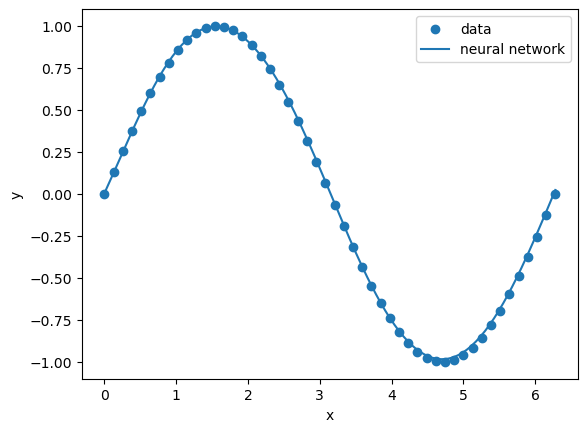

In [1]:
# PyTorch code to illustrate the concept of "universal approximation
# theorem": any function x -> y = f(x) in a compact domain of x can be
# approximated arbitrary close by a one hidden-layer network provided
# the number of hidden units is large enough. 

import numpy
import torch
import matplotlib.pyplot as plt

# Training data
# a curve drawn with 50 points from 0 to 2pi, for the sin(x)
# function, reshaped to 50 by 1  (-1) means we calculation in 
# that dimension, nnLinear(1,3) need tensor of shape (*,1)
x = torch.linspace(0, 2*torch.pi, 50).reshape(-1, 1)
y = torch.sin(x)

# Neural network: 1 input -> 3 hidden units -> 1 output
# We use tanh activation function as indicated on page
# 182 in Figure 6.10.  nn.Sequential() is a short-cut to 
# define subclass of nn.Module and then implement the forward().
model = torch.nn.Sequential(
    torch.nn.Linear(1, 3),
    torch.nn.Tanh(),
    torch.nn.Linear(3, 1)
)

# use mean squared error loss
loss_fn = torch.nn.MSELoss()

# SGD optimizer, stochastic gradient descent
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

# Training loop
for epoch in range(60000):

    # Forward pass
    y_pred = model(x)
    # Calculate loss
    loss = loss_fn(y_pred, y)
    # Backward pass, zero the gradient first
    optimizer.zero_grad()
    loss.backward()
    # do w <- w - lr*grad loss
    optimizer.step()

    # Print loss occasionally
    if epoch % 5000 == 0:
        print(epoch, loss.item())

# Make a smooth curve for plotting, take 200 points
# x or x_plot is the "design matrix"
x_plot = torch.linspace(0, 2*torch.pi, 200).reshape(-1, 1)

with torch.no_grad():
    y_plot = model(x_plot)

# Plot data and fitted curve
plt.scatter(x, y, label="data")
plt.plot(x_plot, y_plot, label="neural network")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()